In [60]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

#coffee_data = pd.read_csv(r"..\data\reduced_data_num.csv")
coffee_data = pd.read_csv(r"..\data\reduced_data_bin.csv")



In [61]:
from sklearn.model_selection import train_test_split

In [62]:
# Filter for caffeinated samples
df_reg = coffee_data[coffee_data['caffeine_class'] == 1].copy()
X_reg = df_reg.drop(columns=['caffeine_class', 'caffeine_percent'])
y_reg = df_reg['caffeine_percent']

X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
feature_names = X_train.columns  # if X_train is a DataFrame

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, cross_val_predict, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

# Define interpretable models
models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("regressor", LinearRegression())
    ]),
    "Lasso Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("regressor", Lasso(alpha=0.01))
    ]),
    "Decision Tree": DecisionTreeRegressor(max_depth=3, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

# Evaluate each model using cross-validation and collect metrics
cv = KFold(n_splits=10, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    y_pred = cross_val_predict(model, X_train, y_train, cv=cv)
    mae = mean_absolute_error(y_train, y_pred)
    mse = mean_squared_error(y_train, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_train, y_pred)
    results[name] = {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

# Fit Random Forest for permutation importance
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
perm_importance = permutation_importance(rf_model, X_train, y_train, n_repeats=10, random_state=42)

# Organize permutation importance
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": perm_importance.importances_mean
}).sort_values(by="Importance", ascending=False)

results_df = pd.DataFrame(results).T
results_df, importance_df


(                        MAE       MSE      RMSE          R2
 Linear Regression  0.847403  5.313787  2.305165 -160.365048
 Lasso Regression   0.096783  0.035092  0.187327   -0.065633
 Decision Tree      0.090583  0.045824  0.214065   -0.391546
 Random Forest      0.093523  0.042654  0.206527   -0.295271,
                 Feature  Importance
 34        env_76_soi_11    0.303804
 10  clim_40_temp_season    0.126511
 16           env_73_asp    0.096297
 17        env_74_solrad    0.045239
 14           env_71_alt    0.039236
 ..                  ...         ...
 83        env_78_wat_18    0.000000
 87         env_78_wat_0    0.000000
 29         env_76_soi_9   -0.000004
 30         env_76_soi_7   -0.000080
 74         env_78_wat_4   -0.000109
 
 [88 rows x 2 columns])

: 

Cross-validating Linear Regression
Cross-validating SVR
Cross-validating KNN
Cross-validating Decision Tree
Cross-validating Random Forest


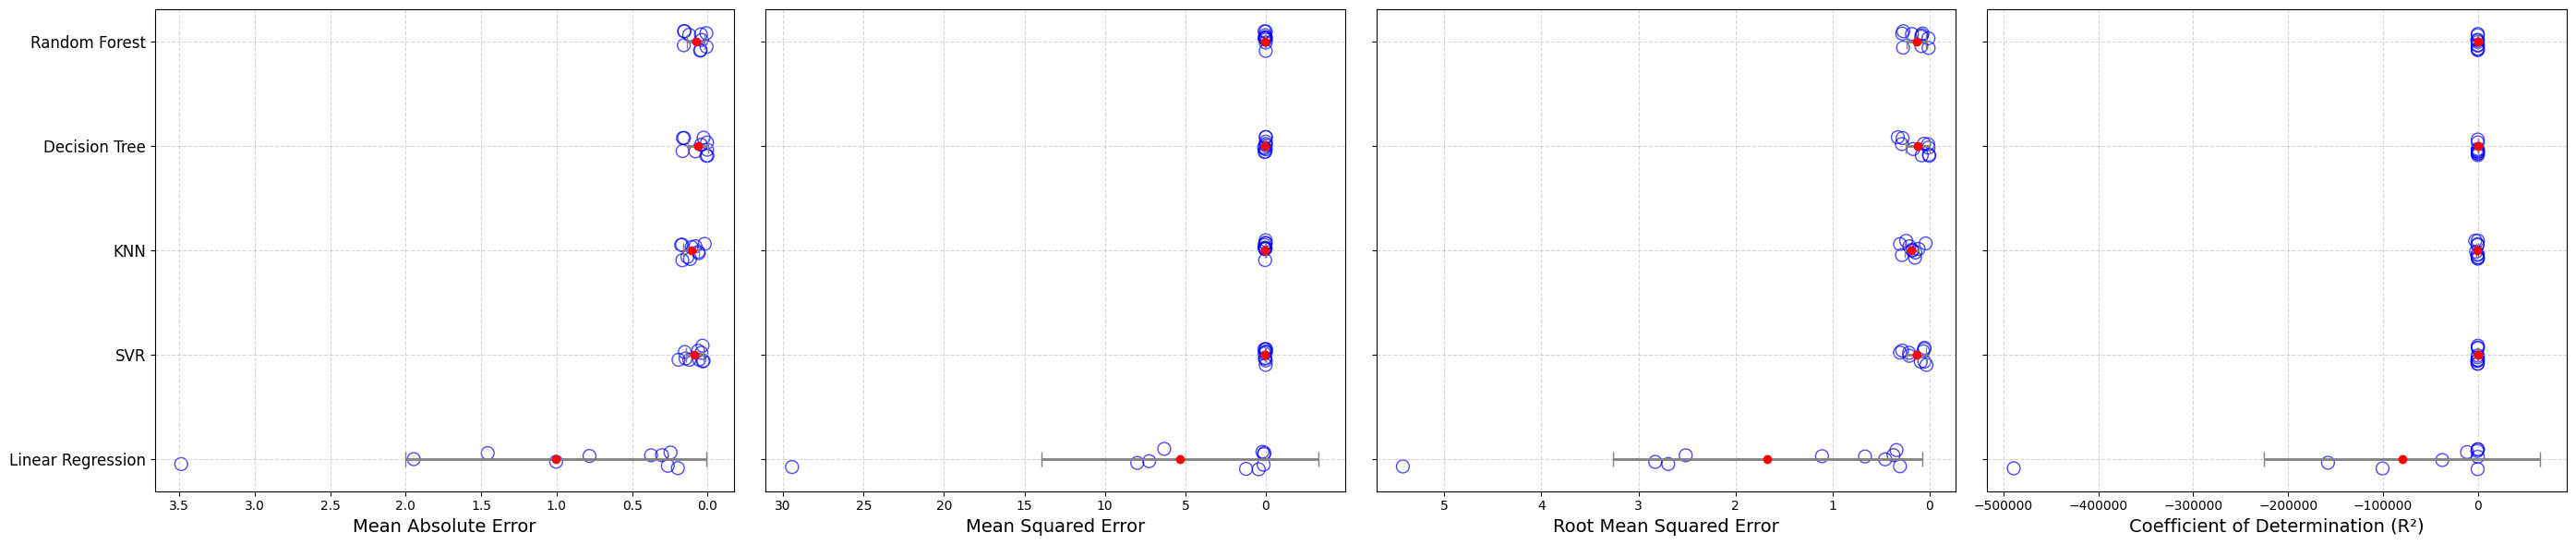

In [45]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.base           import clone
from sklearn.dummy          import DummyRegressor
from sklearn.pipeline       import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV, cross_validate
from sklearn.metrics       import make_scorer, mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model  import LinearRegression, Lasso, Ridge
from sklearn.tree          import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
# -----------------------------------------------------------------------------
# 1) Define interpretable models
# -----------------------------------------------------------------------------
# models = [
#     ("Baseline (Mean Predictor)", DummyRegressor(strategy="mean")),
#     ("Linear Regression",         Pipeline([
#         ("scaler", StandardScaler()),
#         ("model",  LinearRegression())
#     ])),
#     ("Lasso Regression",          Pipeline([
#         ("scaler", StandardScaler()),
#         ("model",  Lasso(random_state=42))
#     ])),
#     ("Ridge Regression",          Pipeline([
#         ("scaler", StandardScaler()),
#         ("model",  Ridge(random_state=42))
#     ])),
#     ("Decision Tree Regressor",   DecisionTreeRegressor(random_state=42))
# ]
models = [
    ("Linear Regression", Pipeline([
        ("scaler", StandardScaler()), 
        ("model", LinearRegression())
    ])),
    ("SVR", Pipeline([
        ("scaler", StandardScaler()), 
        ("model", SVR())
    ])),
    ("KNN", Pipeline([
        ("scaler", StandardScaler()), 
        ("model", KNeighborsRegressor())
    ])),
    ("Decision Tree", DecisionTreeRegressor(random_state=42)),
    ("Random Forest", RandomForestRegressor(n_estimators=100, random_state=42))
]
# -----------------------------------------------------------------------------
# 2) Hyperparameter grids
# -----------------------------------------------------------------------------
param_dist = {
    "Lasso Regression": {
        "model__alpha": np.logspace(-4, 1, 20)
    },
    "Ridge Regression": {
        "model__alpha": np.logspace(-4, 1, 20)
    },
    "Decision Tree Regressor": {
        "max_depth":         [3, 5, 7],
        "min_samples_split": [2, 5, 10]
    }
}

# -----------------------------------------------------------------------------
# 3) Tune where needed
# -----------------------------------------------------------------------------
tuned_models = []
for name, est in models:
    if name in param_dist:
        print(f"Tuning {name}…")
        rs = RandomizedSearchCV(
            est,
            param_dist[name],
            n_iter=20,
            cv=5,
            scoring="neg_mean_squared_error",
            n_jobs=-1,
            random_state=42
        )
        rs.fit(X_train, y_train)
        print(f"  Best params for {name}: {rs.best_params_}")
        tuned_models.append((name, rs.best_estimator_))
    else:
        tuned_models.append((name, est))

# -----------------------------------------------------------------------------
# 4) Cross-validate to collect MAE, MSE, RMSE, R2
# -----------------------------------------------------------------------------
scoring = {
    "MAE": make_scorer(mean_absolute_error, greater_is_better=False),
    "MSE": make_scorer(mean_squared_error,  greater_is_better=False),
    "R2":  make_scorer(r2_score)
}

cv_results = {}
for name, est in tuned_models:
    print("Cross-validating", name)
    res = cross_validate(
        est,
        X_train,
        y_train,
        cv=10,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )
    mae = -res["test_MAE"]
    mse = -res["test_MSE"]
    rmse = np.sqrt(mse)
    r2 = res["test_R2"]
    cv_results[name] = {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

# -----------------------------------------------------------------------------
# 5) Plot jitter + mean±std bars
# -----------------------------------------------------------------------------
metrics = ["MAE", "MSE", "RMSE", "R2"]
xlabel_map = {
    "MAE":  "Mean Absolute Error",
    "MSE":  "Mean Squared Error",
    "RMSE": "Root Mean Squared Error",
    "R2":   "Coefficient of Determination (R\u00b2)"
}

fig, axes = plt.subplots(1, len(metrics), figsize=(28, 6), sharey=True)
for ax, metric in zip(axes, metrics):
    for i, (name, _) in enumerate(tuned_models):
        scores = cv_results[name][metric]
        ax.scatter(
            scores,
            i + np.random.uniform(-0.1, 0.1, len(scores)),
            edgecolor="blue",
            facecolors="none",
            alpha=0.7,
            s=100
        )
    means = [cv_results[name][metric].mean() for name, _ in tuned_models]
    stds  = [cv_results[name][metric].std()  for name, _ in tuned_models]
    ax.errorbar(
        means,
        range(len(tuned_models)),
        xerr=stds,
        fmt="o",
        color="red",
        ecolor="gray",
        elinewidth=2,
        capsize=6
    )
    ax.set_yticks(range(len(tuned_models)))
    ax.set_yticklabels([name for name, _ in tuned_models], fontsize=12)
    ax.set_xlabel(xlabel_map[metric], fontsize=14)
    ax.grid(True, linestyle="--", alpha=0.5)
    if metric in ("MAE", "MSE", "RMSE"):
        ax.invert_xaxis()  # smaller is better

plt.tight_layout()
plt.show()


since model chosen to maintain interpretability failed in predicting better than simple mean, I tried new lib `interpret`

In [35]:
!pip install interpret


     ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
     ---------------------------------------- 4.0/4.0 MB 47.8 MB/s eta 0:00:00
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ---------------------------------------- 0.0/16.5 MB ? eta -:--:--
   ---------------------------------------- 16.5/16.5 MB 103.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
   ---------------------------------------- 7.8/7.8 MB 96.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 91.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/15.6 MB ? eta -:--:--
   ------------------- -------------------- 7.6/15.6 MB 36.2 MB/s eta 0:00:01
   ---------------------------------------  15.5/15.6 MB 40.5 MB/s eta 0:00:01
   ---------------------------------------- 15.6/15.6 MB 36.4 MB/s eta 0:00:00


  You can safely remove it manually.
  You can safely remove it manually.

[notice] A new release of pip is available: 25.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Tuning Lasso Regression (n_iter=20, cv=10)…
Fitting 10 folds for each of 20 candidates, totalling 200 fits
  → Best Lasso Regression params: {'model__alpha': np.float64(0.012742749857031334)}
Tuning Ridge Regression (n_iter=20, cv=10)…
Fitting 10 folds for each of 20 candidates, totalling 200 fits
  → Best Ridge Regression params: {'model__alpha': np.float64(10.0)}
Tuning Decision Tree Regressor (n_iter=20, cv=10)…


c:\Users\adm1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 9 is smaller than n_iter=20. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 10 folds for each of 9 candidates, totalling 90 fits
  → Best Decision Tree Regressor params: {'min_samples_split': 2, 'max_depth': 5}

Running 10-fold CV on all models…


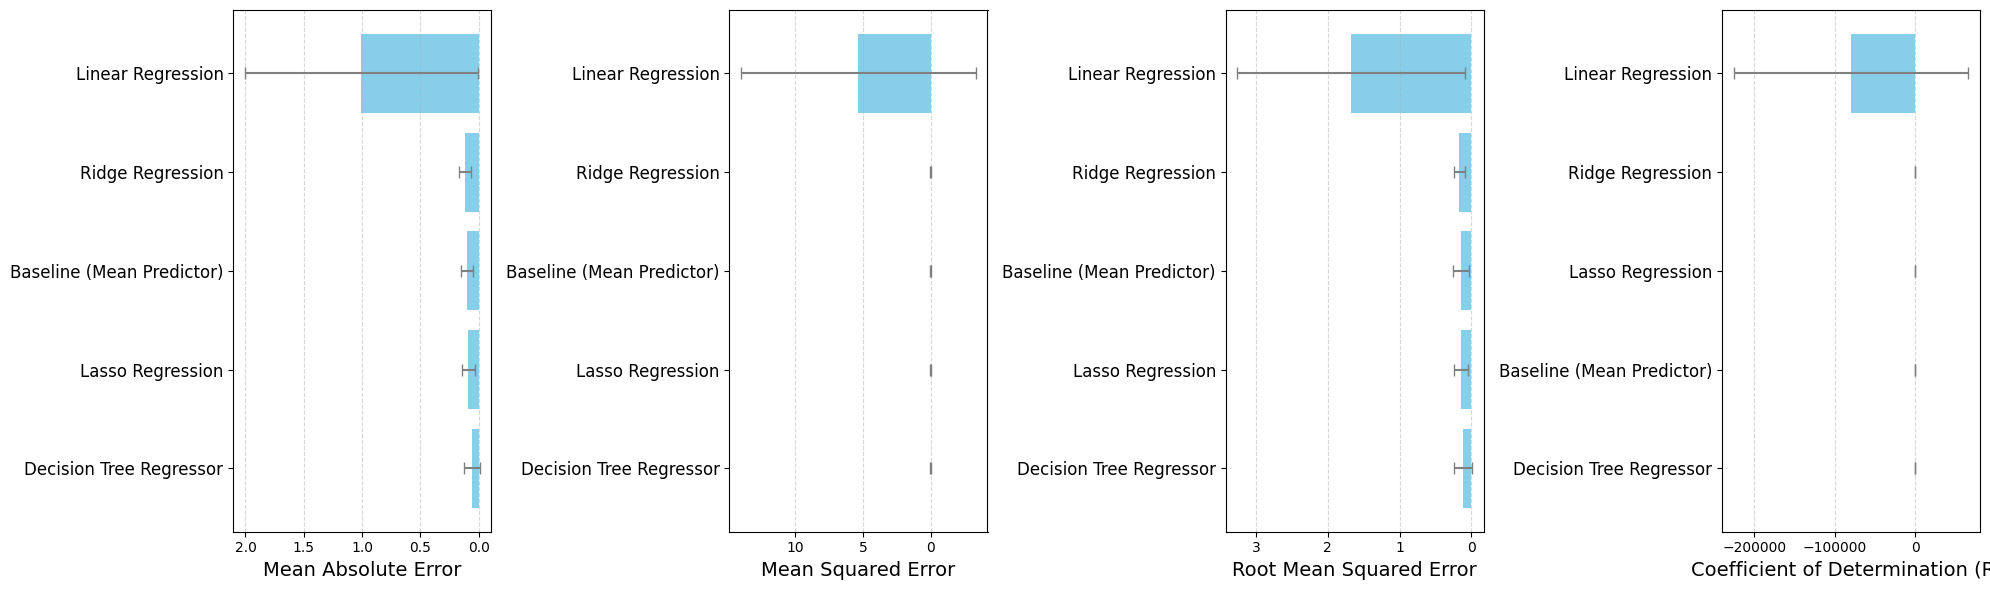

In [42]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.dummy          import DummyRegressor
from sklearn.pipeline       import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV, cross_validate
from sklearn.metrics       import r2_score

from sklearn.linear_model  import LinearRegression, Lasso, Ridge
from sklearn.tree          import DecisionTreeRegressor

# -----------------------------------------------------------------------------
# 1) Define your interpretable models
# -----------------------------------------------------------------------------
models = [
    ("Baseline (Mean Predictor)", DummyRegressor(strategy="mean")),
    ("Linear Regression",         Pipeline([
        ("scaler", StandardScaler()),
        ("model",  LinearRegression())
    ])),
    ("Lasso Regression",          Pipeline([
        ("scaler", StandardScaler()),
        ("model",  Lasso(random_state=42))
    ])),
    ("Ridge Regression",          Pipeline([
        ("scaler", StandardScaler()),
        ("model",  Ridge(random_state=42))
    ])),
    ("Decision Tree Regressor",   DecisionTreeRegressor(random_state=42))
]

# -----------------------------------------------------------------------------
# 2) Hyperparameter distributions
# -----------------------------------------------------------------------------
param_dist = {
    "Lasso Regression": {
        "model__alpha": np.logspace(-4, 1, 20)
    },
    "Ridge Regression": {
        "model__alpha": np.logspace(-4, 1, 20)
    },
    "Decision Tree Regressor": {
        "max_depth":         [3, 5, 7],
        "min_samples_split": [2, 5, 10]
    }
}

# -----------------------------------------------------------------------------
# 3) Tune each model (20 random draws, 10-fold CV)
# -----------------------------------------------------------------------------
tuned = []
for name, est in models:
    if name in param_dist:
        print(f"Tuning {name} (n_iter=20, cv=10)…")
        rs = RandomizedSearchCV(
            est,
            param_dist[name],
            n_iter=20,
            cv=10,
            scoring="neg_mean_squared_error",
            n_jobs=-1,
            verbose=1,
            random_state=42
        )
        rs.fit(X_train, y_train)
        print(f"  → Best {name} params: {rs.best_params_}")
        tuned.append((name, rs.best_estimator_))
    else:
        tuned.append((name, est))

# -----------------------------------------------------------------------------
# 4) Cross-validate to collect MAE, MSE, RMSE, R²
# -----------------------------------------------------------------------------
scoring = {
    "MAE": "neg_mean_absolute_error",
    "MSE": "neg_mean_squared_error",
    "R2":  "r2"
}

cv_results = {}
print("\nRunning 10-fold CV on all models…")
for name, est in tuned:
    res = cross_validate(
        est,
        X_train,
        y_train,
        cv=10,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1,
        verbose=0
    )
    mae  = -res["test_MAE"]
    mse  = -res["test_MSE"]
    rmse = np.sqrt(mse)
    r2   =  res["test_R2"]

    cv_results[name] = {"MAE":mae, "MSE":mse, "RMSE":rmse, "R2":r2}

# -----------------------------------------------------------------------------
# 5) Plot per-fold jitter + red mean±std, clamp R² axis to [–1,1]
# -----------------------------------------------------------------------------

metrics   = ["MAE","MSE","RMSE","R2"]
xlabel_map = {
    "MAE":  "Mean Absolute Error",
    "MSE":  "Mean Squared Error",
    "RMSE": "Root Mean Squared Error",
    "R2":   "Coefficient of Determination (R\u00b2)"
}

fig, axes = plt.subplots(1, len(metrics), figsize=(20, 6), sharey=False)

for ax, metric in zip(axes, metrics):
    # compute the mean & std for each model
    means = {name: cv_results[name][metric].mean() 
             for name in cv_results}
    stds  = {name: cv_results[name][metric].std()  
             for name in cv_results}

    # sort models: for error metrics, smaller is better; for R2, larger is better
    reverse = (metric == "R2")
    sorted_names = sorted(means, key=lambda n: means[n], reverse=reverse)

    y = np.arange(len(sorted_names))
    bar_vals = [means[n] for n in sorted_names]
    bar_errs = [stds[n]  for n in sorted_names]

    ax.barh(y, bar_vals, xerr=bar_errs, align="center", color="skyblue", ecolor="gray", capsize=4)
    ax.set_yticks(y)
    ax.set_yticklabels(sorted_names, fontsize=12)
    ax.set_xlabel(xlabel_map[metric], fontsize=14)
    ax.grid(True, axis="x", linestyle="--", alpha=0.5)

    # invert x‐axis on errors so “smaller is better” reads left → right
    if metric in ("MAE","MSE","RMSE"):
        ax.invert_xaxis()

plt.tight_layout()
plt.show()


Explainable Boosting Machine (EBM)

- CV‐based MAE/MSE/RMSE/R² for EBM alone, plotted just as you did before.

- A full “shape‐plot” for each feature, showing exactly how coffee content varies with each environmental covariate (and any learned pairwise interactions).

CVizing EBM…


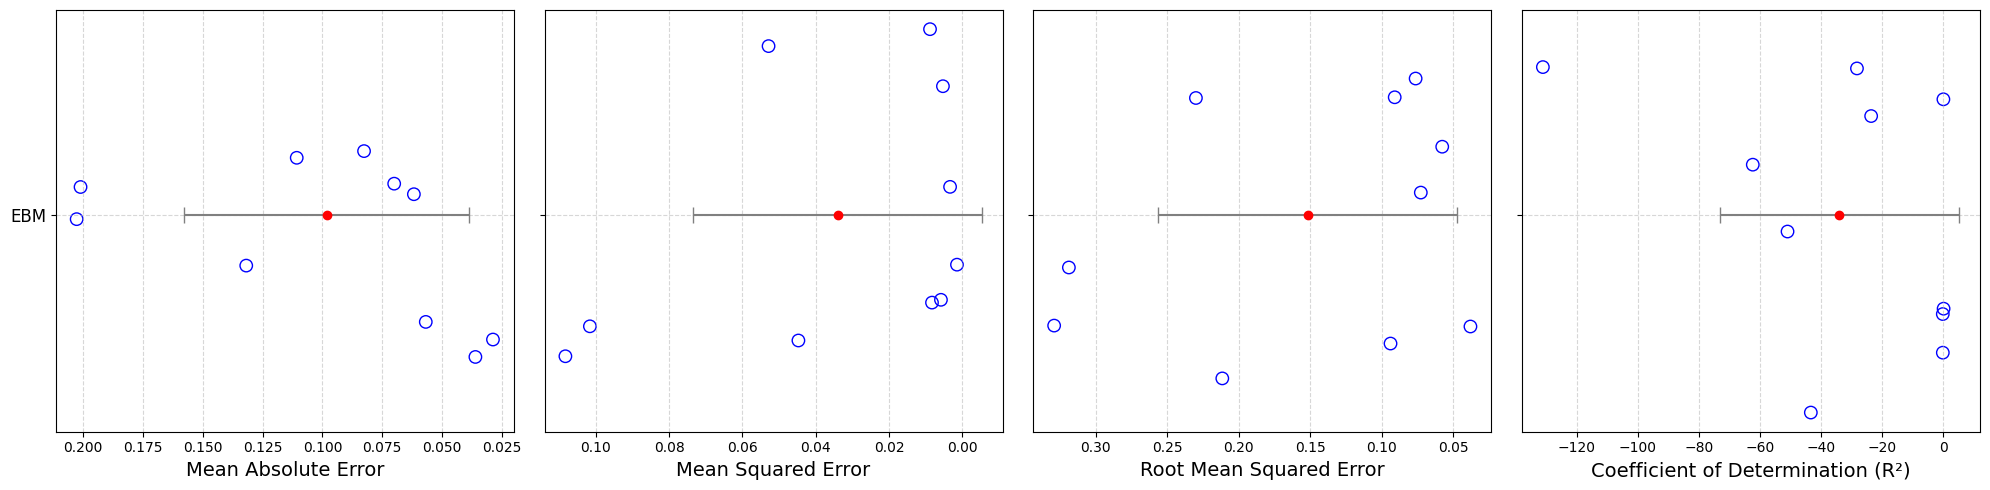

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from interpret.glassbox      import ExplainableBoostingRegressor
from interpret import set_visualize_provider
from sklearn.model_selection import cross_validate, KFold
from sklearn.metrics         import mean_absolute_error, mean_squared_error, r2_score

# 1a) Build & CV the EBM
#ebm = ExplainableBoostingRegressor(random_state=42)
ebm = ExplainableBoostingRegressor(
    n_jobs=-1,               # use all cores
    outer_bags=10,           # default 50 → fewer bagged models
    max_bins=64,             # default 255 → fewer histogram bins
    max_rounds=50,           # default 100 → fewer boosting iterations
    interactions=(),         # disable all pairwise interactions
    random_state=42
)

cv = KFold(n_splits=10, shuffle=True, random_state=42)

scoring = {
    "MAE":  lambda est, X, y: -mean_absolute_error(y,  est.predict(X)),
    "MSE":  lambda est, X, y: -mean_squared_error(y,  est.predict(X)),
    "RMSE": lambda est, X, y: -np.sqrt(mean_squared_error(y, est.predict(X))),
    "R2":   lambda est, X, y:  r2_score(y, est.predict(X))
}

print("CVizing EBM…")
res = cross_validate(
    ebm, 
    X_train, 
    y_train, 
    cv=cv, 
    scoring=scoring, 
    return_train_score=False,
    n_jobs=-1
)

# flip the neg‐errors back to positive
results = {
    "MAE":  -res["test_MAE"],
    "MSE":  -res["test_MSE"],
    "RMSE": -res["test_RMSE"],
    "R2":    res["test_R2"]
}

# 1b) Plot performance (same barh style as before)
metrics   = ["MAE","MSE","RMSE","R2"]
xlabel_map = {
    "MAE":  "Mean Absolute Error",
    "MSE":  "Mean Squared Error",
    "RMSE": "Root Mean Squared Error",
    "R2":   "Coefficient of Determination (R\u00b2)"
}

fig, axes = plt.subplots(1, len(metrics), figsize=(20,5), sharey=True)
for ax, metric in zip(axes, metrics):
    scores = results[metric]
    y = np.arange(1)  # only one model
    ax.scatter(
        scores, 
        y + np.random.uniform(-0.1,0.1,len(scores)), 
        edgecolor="blue", facecolors="none", s=80
    )
    mean, std = scores.mean(), scores.std()
    ax.errorbar([mean], [0], xerr=[std],
                fmt="o", color="red", ecolor="gray", capsize=6)
    ax.set_yticks([0])
    ax.set_yticklabels(["EBM"], fontsize=12)
    ax.set_xlabel(xlabel_map[metric], fontsize=14)
    if metric in ("MAE","MSE","RMSE"):
        ax.invert_xaxis()
    ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# 1c) Global explanations
ebm.fit(X_train, y_train)
#set_visualize_provider("svg")  # high‐quality inline
exp = ebm.explain_global()
exp.visualize()


EBM: I can't really rely on this model since barely better than basline

Mixed‐Effects Model (random intercept per species)

- Fixed‐effect coefficients for each environmental predictor (exactly like a linear model).

- Species‐level intercepts that soak up baseline differences.

- A glance at overall goodness‐of‐fit and how much variance your covariates explain within species.

In [59]:
#species_data = pd.read_csv(r"..\data\cleaned_data_w_class.csv")
species_data = pd.read_csv(r"..\data\cleaned_data_w_class.csv")

species_data.head


<bound method NDFrame.head of      clim_1_tmin1_jan  clim_2_tmin2_feb  clim_3_tmin3_mar  clim_4_tmin4_apr  \
0               195.5             195.0             186.0             169.0   
1               177.5             177.0             170.0             153.0   
2               177.5             177.0             170.0             153.0   
3               208.5             208.0             200.0             182.0   
4               177.5             177.0             170.0             153.0   
..                ...               ...               ...               ...   
445             216.0             215.0             210.0             197.0   
446             208.0             207.0             203.0             189.0   
447             211.0             210.0             206.0             192.0   
448             216.0             215.0             210.0             197.0   
449             214.0             213.0             209.0             196.0   

     clim_5_tmin5_may

In [53]:
import pandas as pd
import statsmodels.formula.api as smf

# assume X_train is a DataFrame and you have a 'species' column alongside your predictors
df = X_train.copy()
df["caffeine"] = y_train
# build a formula: caffeine ~ all numeric predictors + (1 | species)
predictors = "+".join([c for c in X_train.columns if c!="species"])
formula    = f"caffeine ~ {predictors}"

# fit
md = smf.mixedlm(formula, df, groups=df["species"])
mdf = md.fit(method=["lbfgs"])
print(mdf.summary())

# extract fixed‐effect estimates
print("\nFixed‐effects coefficients:")
print(mdf.fe_params)

# extract random intercepts by species
print("\nRandom intercepts:")
print(mdf.random_effects)

# optional: CV on fixed‐effects only (dropping random intercept complexity)
from sklearn.model_selection import cross_val_score
from sklearn.linear_model  import LinearRegression

X_fe = df.drop(columns=["caffeine","species"])
y_fe = df["caffeine"]
regr = LinearRegression()
scores = cross_val_score(regr, X_fe, y_fe, cv=10, scoring="neg_mean_squared_error")
print("CV RMSE (fixed‐effects only):", np.sqrt(-scores).mean())


KeyError: 'species'